In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram


BASE_DIR = Path(r"C:\Users\szymo\Desktop\Wibracje\Datasety\Wibracje wyważanie\processed")

TIME_COL = "Time_s"
ALL_COLS = ["Time_s", "ACXXX_SN1 [g]", "ACXXX_SN2 [g]", "Tacho_Ch8 [Hz]"]
SPECTROGRAM_COLS = ["ACXXX_SN1 [g]", "ACXXX_SN2 [g]"]

F_MAX_HZ = 5000

F_MIN_HZ = 1

In [ ]:
def natural_key(path):
    return [int(x) if x.isdigit() else x.lower() for x in re.split(r"(\d+)", path.name)]


def infer_sampling_frequency(file_path):
    time = pd.read_csv(file_path, usecols=[TIME_COL])[TIME_COL]
    time = pd.to_numeric(time, errors="coerce").dropna().to_numpy()

    dt = np.diff(time)
    dt = dt[np.isfinite(dt) & (dt > 0)]

    return 1 / np.median(dt)


def read_data(file_path):
    df = pd.read_csv(file_path, usecols=ALL_COLS)

    for col in ALL_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def get_complex_spectrogram(x, fs):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    nperseg = 2**15
    noverlap = nperseg // 2

    f, t, Zxx = spectrogram(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="spectrum",
        mode="complex",
    )

    return f, t, Zxx

In [ ]:
def plot_2x2_signal_phase(df, fs, file_path, f_max_hz=F_MAX_HZ, f_min_hz=F_MIN_HZ):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=True)

    for col_idx, signal_col in enumerate(SPECTROGRAM_COLS):
        x = df[signal_col].to_numpy()

        f, t, Zxx = get_complex_spectrogram(x, fs)
        print("f", f.shape)
        print("t", t.shape)
        print("z", Zxx.shape)

        freq_mask = (f >= f_min_hz) & (f <= f_max_hz)
        f_plot = f[freq_mask]
        Z_plot = Zxx[freq_mask, :]
        
        print("f_plot", f_plot.shape)
        print("Z_plot", Z_plot.shape)
        

        amplitude_db = 20 * np.log10(np.abs(Z_plot) + np.finfo(float).eps)
        phase_rad = np.angle(Z_plot)

        ax_amp = axes[0, col_idx]
        im_amp = ax_amp.pcolormesh(t, f_plot, amplitude_db, shading="gouraud")
        ax_amp.set_title(f"{signal_col} | amplitude")
        ax_amp.set_ylabel("Frequency [Hz]")
        ax_amp.set_yscale("log")
        ax_amp.set_ylim(f_min_hz, f_max_hz)
        fig.colorbar(im_amp, ax=ax_amp, label="Amplitude [dB]")

        ax_phase = axes[1, col_idx]
        im_phase = ax_phase.pcolormesh(t, f_plot, phase_rad, shading="gouraud")
        ax_phase.set_title(f"{signal_col} | phase")
        ax_phase.set_xlabel("Time [s]")
        ax_phase.set_ylabel("Frequency [Hz]")
        ax_phase.set_yscale("log")
        ax_phase.set_ylim(f_min_hz, f_max_hz)
        fig.colorbar(im_phase, ax=ax_phase, label="Phase [rad]")

    fig.suptitle(file_path.name, fontsize=14)
    plt.tight_layout()
    plt.show()

Found 322 files
v01_14_a1_sr_processed.csv
Sampling frequency: 32768.000000 Hz
f (16385,)
t (21,)
z (16385, 21)
f_plot (5000,)
Z_plot (5000, 21)
f (16385,)
t (21,)
z (16385, 21)
f_plot (5000,)
Z_plot (5000, 21)


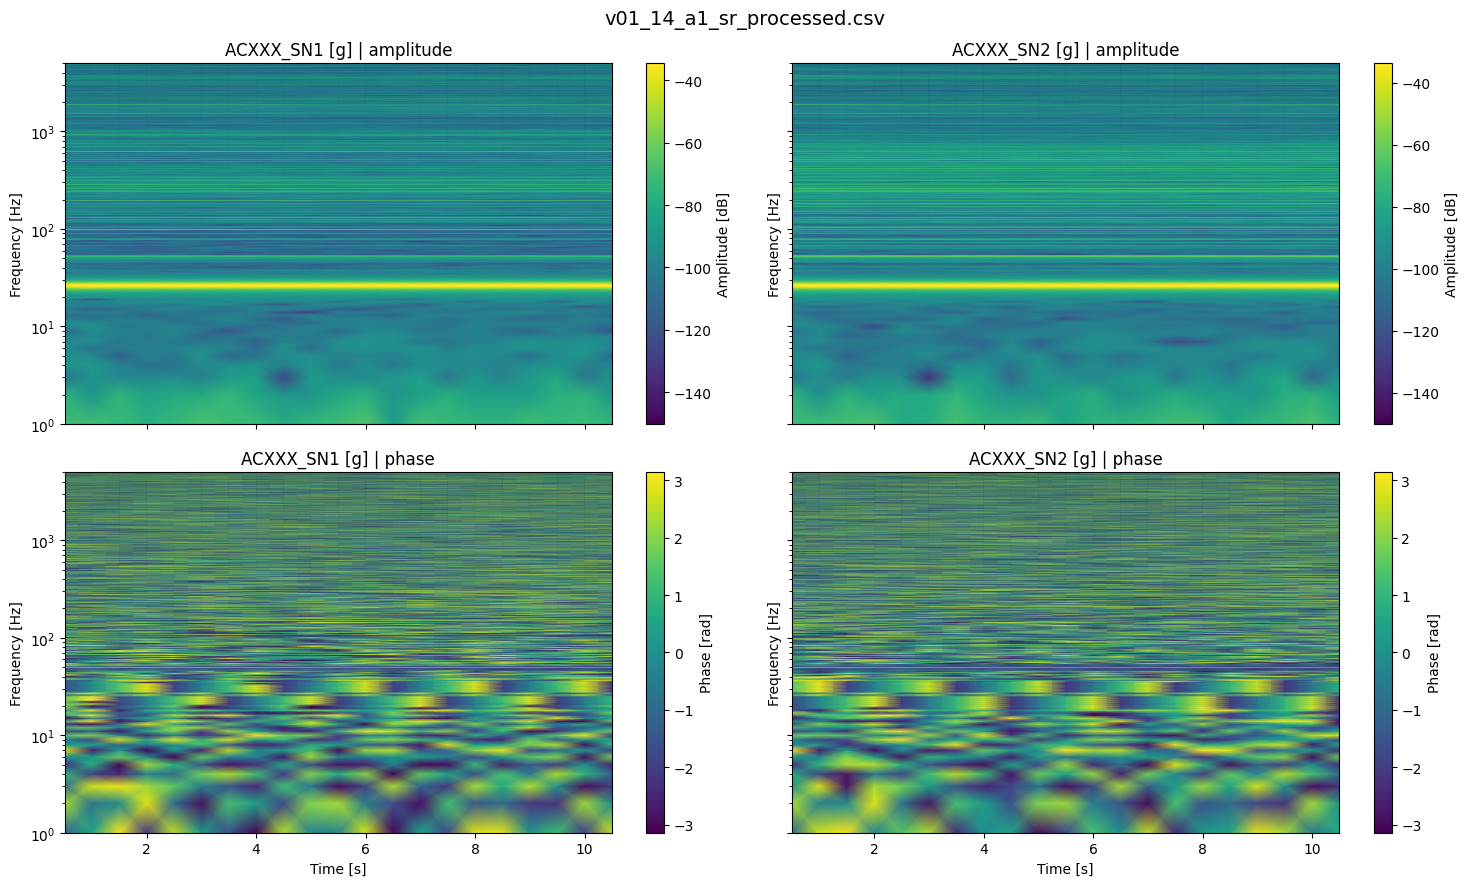

In [ ]:
files = sorted(
    [p for p in BASE_DIR.glob("*_processed*") if p.is_file()],
    key=natural_key,
)

print(f"Found {len(files)} files")

for p in files[:1]:
    print(p.name)

fs = infer_sampling_frequency(files[0])
print(f"Sampling frequency: {fs:.6f} Hz")

for file_path in files[:1]:
    df = read_data(file_path)
    plot_2x2_signal_phase(df, fs, file_path, f_max_hz=F_MAX_HZ)